## Customer Subscription Prediction Using SVM

---
### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

---
### Loading & Inspecting Dataset

In [2]:
pd.set_option('display.max_columns', None) ## to show all features in the dataset

df = pd.read_csv('bank-additional-full.csv' , sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,62,admin.,married,high.school,no,yes,no,cellular,may,thu,1068,8,163,9,nonexistent,-1.297,93.012,-42.083,3.007,5151,no
1,54,retired,single,high.school,no,no,yes,cellular,aug,fri,1782,5,126,7,success,-2.221,93.876,-39.391,2.561,5082,no
2,57,technician,married,university.degree,no,yes,no,cellular,feb,wed,1171,9,53,7,nonexistent,-0.980,93.420,-38.894,3.157,5109,no
3,54,blue-collar,married,basic.6y,no,yes,yes,cellular,aug,tue,1886,8,178,10,nonexistent,-0.753,93.808,-38.787,2.949,5131,no
4,49,services,married,high.school,no,yes,no,telephone,may,tue,1108,9,189,11,failure,-1.139,93.318,-41.322,3.187,5088,no


In [3]:
df.shape

(15000, 21)

In [4]:
df.rename(columns={'y' : 'Subscribe'} , inplace= True) ## Rename the target feature

--- 
- **Define X and y**

In [5]:
X = df.drop(columns={'Subscribe'})
y = df['Subscribe'].map({'no' : 0 , 'yes' : 1})

---
- **Splitting Dataset**

In [6]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X, y , test_size= 0.2 , random_state= 42)

print(f'X train shape : {X_train.shape}')
print(f'y train shpee : {y_train.shape}')
print(f'X test shape : {X_test.shape}')
print(f'y test shpee : {y_test.shape}')


X train shape : (12000, 20)
y train shpee : (12000,)
X test shape : (3000, 20)
y test shpee : (3000,)


---
## Exploratory Data Analysis(EDA)

In [7]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 12000 entries, 9839 to 7270
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             12000 non-null  int64  
 1   job             12000 non-null  str    
 2   marital         12000 non-null  str    
 3   education       12000 non-null  str    
 4   default         12000 non-null  str    
 5   housing         12000 non-null  str    
 6   loan            12000 non-null  str    
 7   contact         12000 non-null  str    
 8   month           12000 non-null  str    
 9   day_of_week     12000 non-null  str    
 10  duration        12000 non-null  int64  
 11  campaign        12000 non-null  int64  
 12  pdays           12000 non-null  int64  
 13  previous        12000 non-null  int64  
 14  poutcome        12000 non-null  str    
 15  emp.var.rate    12000 non-null  float64
 16  cons.price.idx  12000 non-null  float64
 17  cons.conf.idx   12000 non-null  float64
 18  

In [8]:
X_train.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,12000.0,53.94,10.03,18.00,47.00,54.00,61.00,95.0
duration,12000.0,1289.50,369.44,10.00,1031.00,1269.00,1526.00,2500.0
campaign,12000.0,8.19,1.80,1.00,7.00,8.00,9.00,15.0
pdays,12000.0,100.44,60.17,1.00,50.00,100.00,149.00,999.0
previous,12000.0,9.68,2.80,0.00,8.00,10.00,12.00,20.0
emp.var.rate,12000.0,-1.25,0.54,-3.18,-1.62,-1.26,-0.91,1.4
cons.price.idx,12000.0,93.52,0.34,92.08,93.32,93.54,93.75,94.8
cons.conf.idx,12000.0,-39.85,2.53,-50.00,-41.54,-39.85,-38.16,-30.0
euribor3m,12000.0,2.86,0.52,0.60,2.51,2.88,3.20,5.0
nr.employed,12000.0,5103.75,35.13,4963.00,5079.00,5104.00,5129.00,5228.0


In [9]:
X_train['job'].value_counts()

job
blue-collar    2687
admin.         2175
services       1809
technician     1362
management     1214
housemaid       969
unemployed      932
retired         852
Name: count, dtype: int64

In [10]:
X_train['marital'].value_counts()


marital
married     7819
single      2984
divorced    1197
Name: count, dtype: int64

In [11]:
for col in X_train.columns:
    unknown_count = ( X_train[col] == 'unknown' ).sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count}")

In [13]:
y_train.value_counts()

Subscribe
0    29245
1     3705
Name: count, dtype: int64

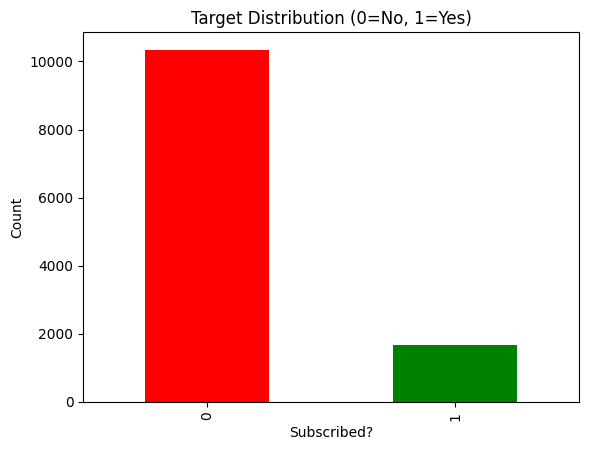

In [12]:
y_train.value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Target Distribution (0=No, 1=Yes)')
plt.xlabel('Subscribed?')
plt.ylabel('Count')
plt.show()

In [13]:
y_train.value_counts(normalize= True) * 100 ## the dataset is imbalanced !! 

Subscribe
0    86.183333
1    13.816667
Name: proportion, dtype: float64

In [14]:
numerical_features = X_train[['age' , 'duration' , 'campaign' , 'pdays',
                              'previous' , 'emp.var.rate' , 'cons.price.idx' , 
                              'cons.conf.idx' , 'euribor3m', 'nr.employed']]

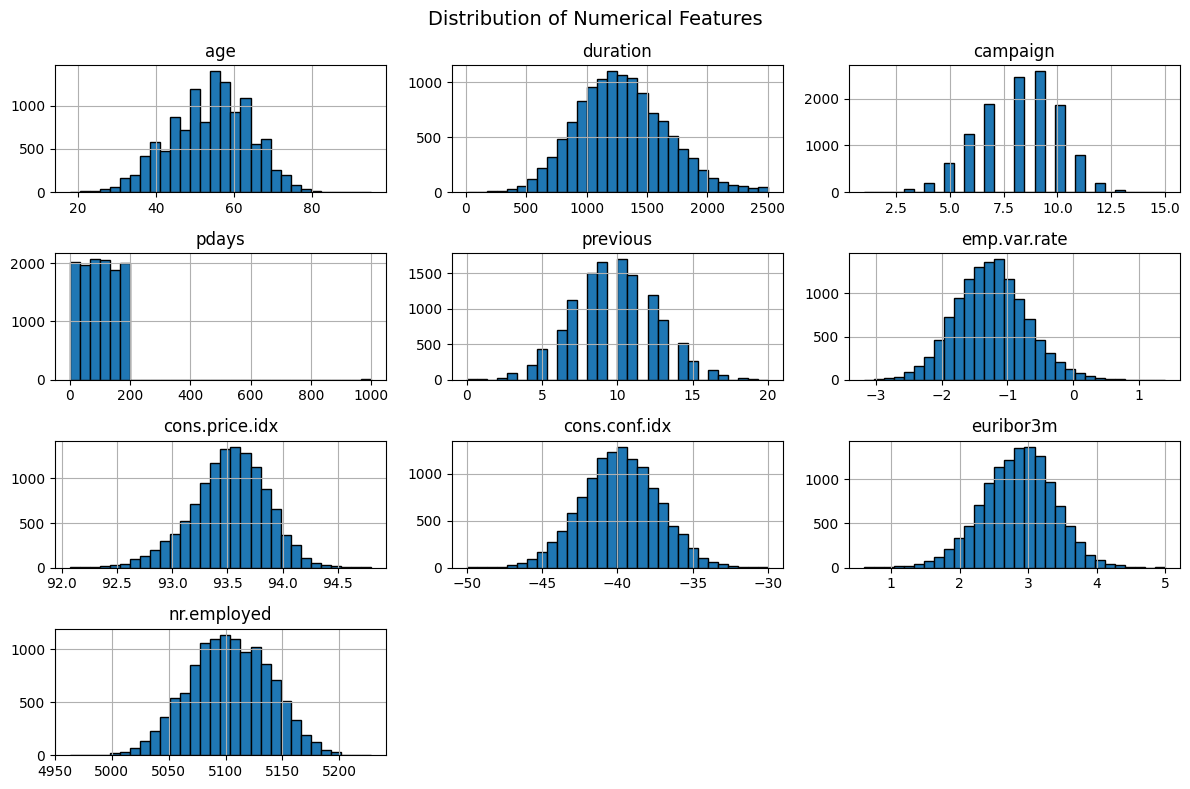

In [15]:
numerical_features.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

<Axes: >

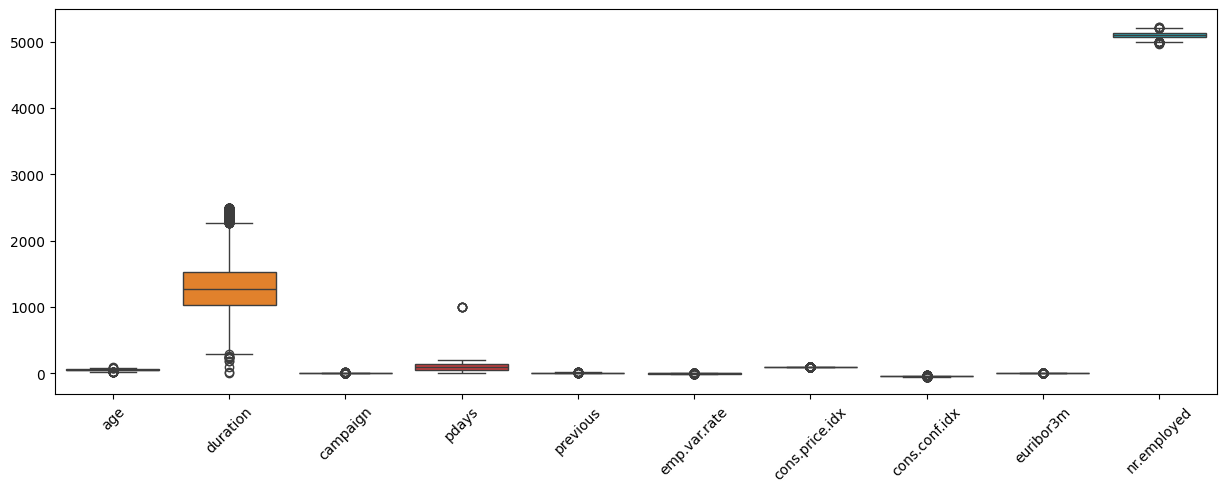

In [16]:
plt.figure(figsize=(15,5))
plt.xticks(rotation = 45)
sns.boxplot(X_train)

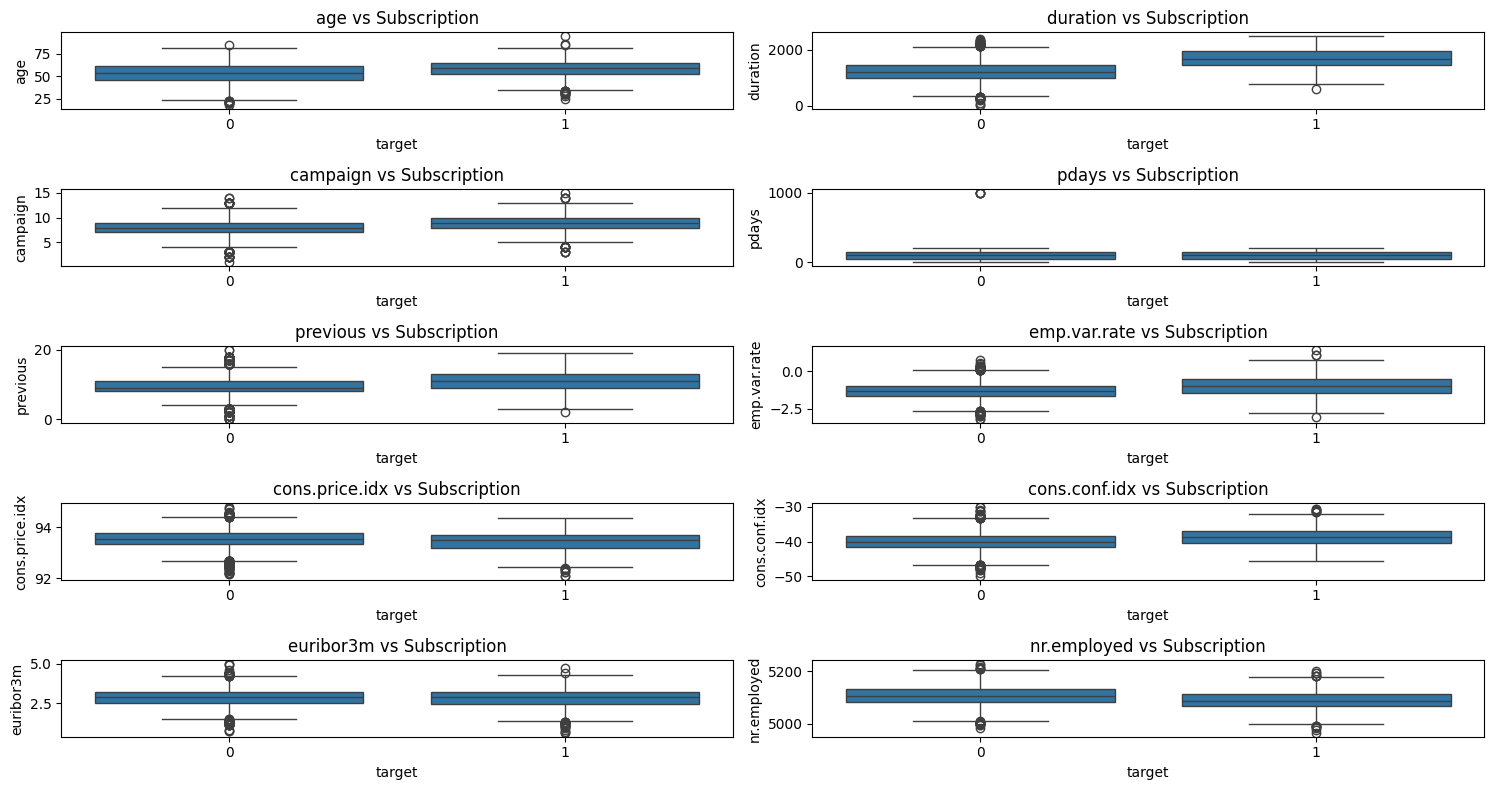

In [17]:
# box plots
fig, axes = plt.subplots(5, 2, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    # Create temporary dataframe
    temp = pd.DataFrame({
        col: X_train[col],
        'target': y_train
    })
    

    sns.boxplot(x='target', y=col, data=temp, ax=axes[i])
    axes[i].set_title(f'{col} vs Subscription')

plt.tight_layout()
plt.show()

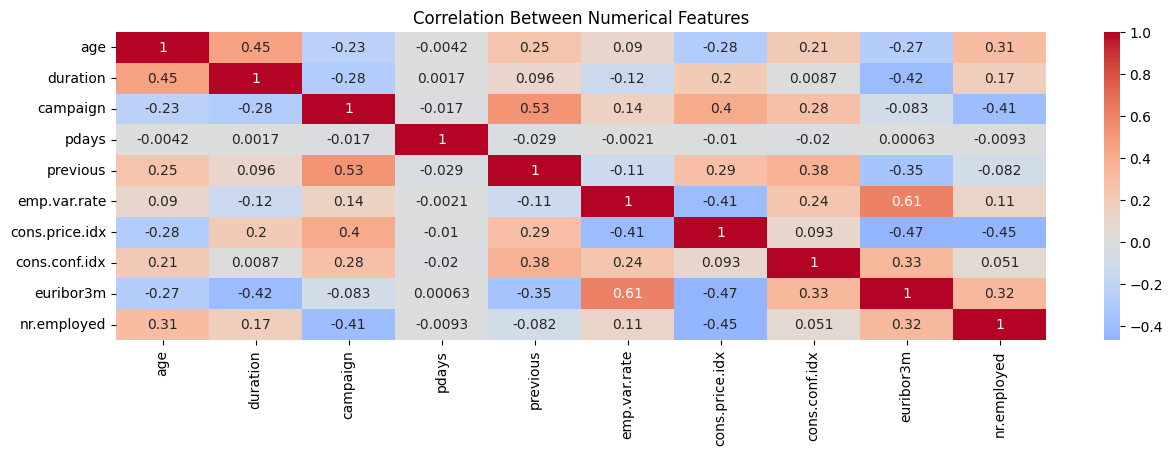

In [18]:
plt.figure(figsize=(15, 4))
sns.heatmap(numerical_features.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numerical Features')
plt.show()


In [19]:
# Which features are most correlated with target?
for col in numerical_features:
    corr_val = X_train[col].corr(y_train)
    print(f"{col}: {corr_val:.2f}")

age: 0.19
duration: 0.45
campaign: 0.17
pdays: 0.00
previous: 0.21
emp.var.rate: 0.22
cons.price.idx: -0.10
cons.conf.idx: 0.17
euribor3m: -0.03
nr.employed: -0.17


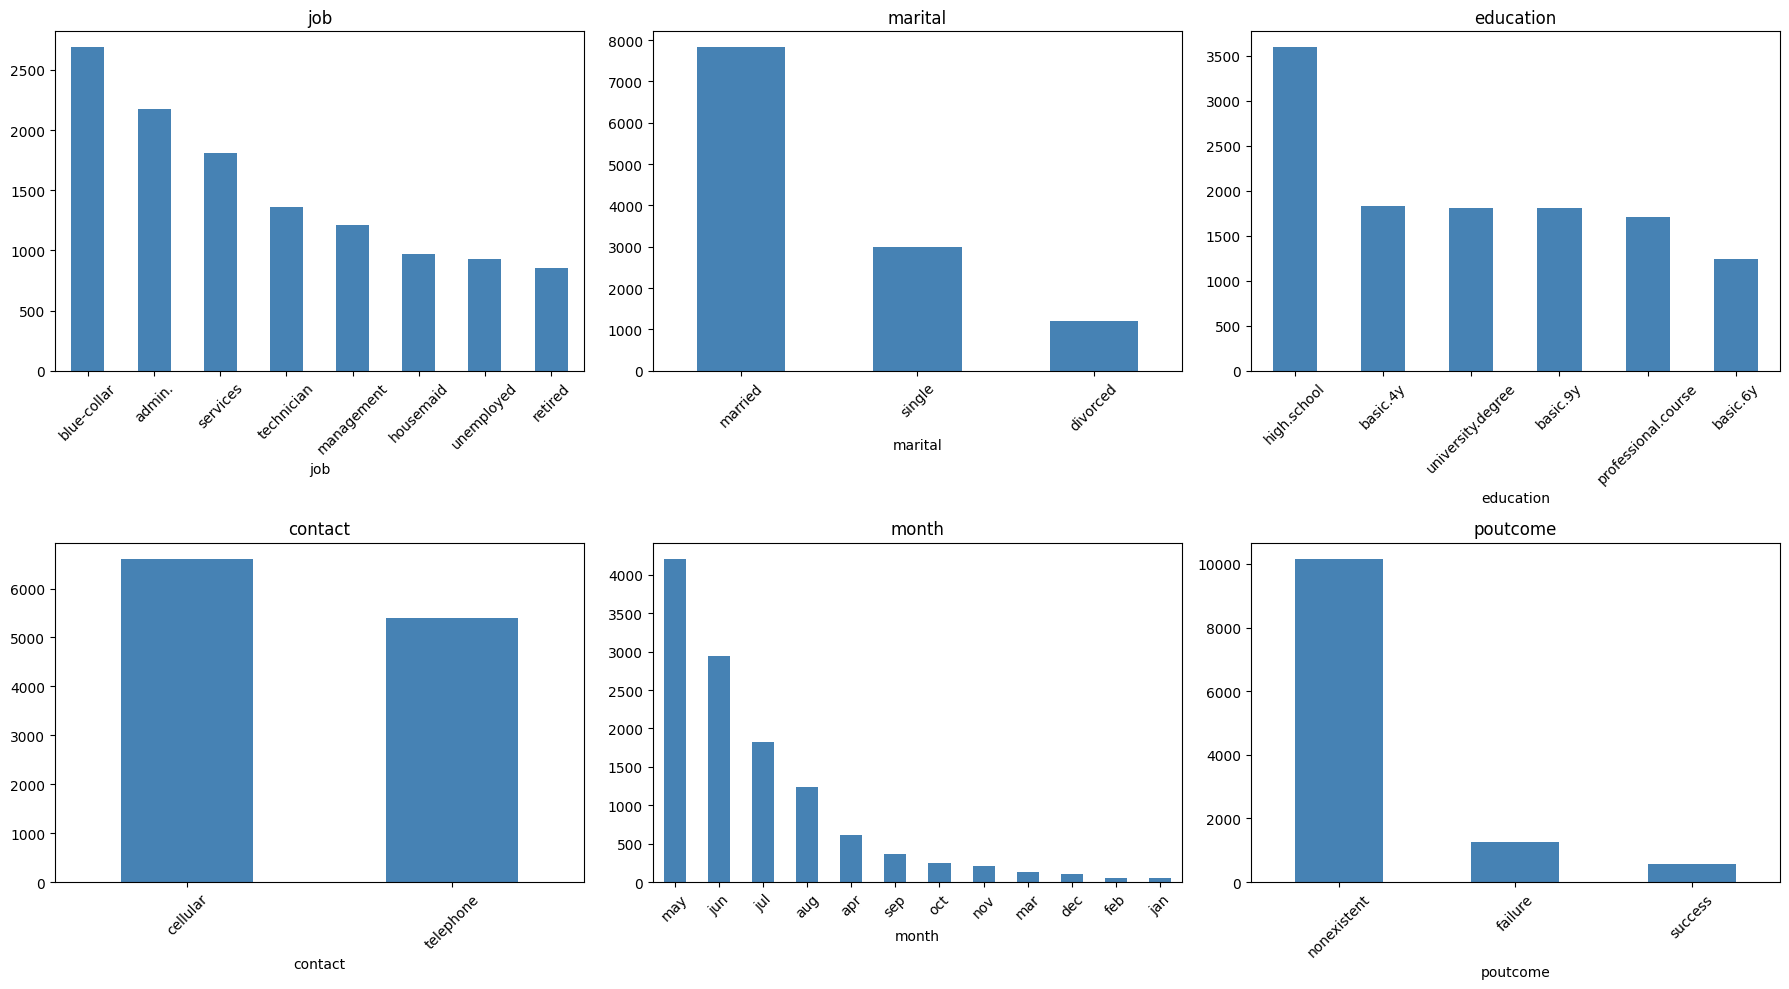

In [20]:

## Categorical Features.

cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

# Plot each
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    X_train[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

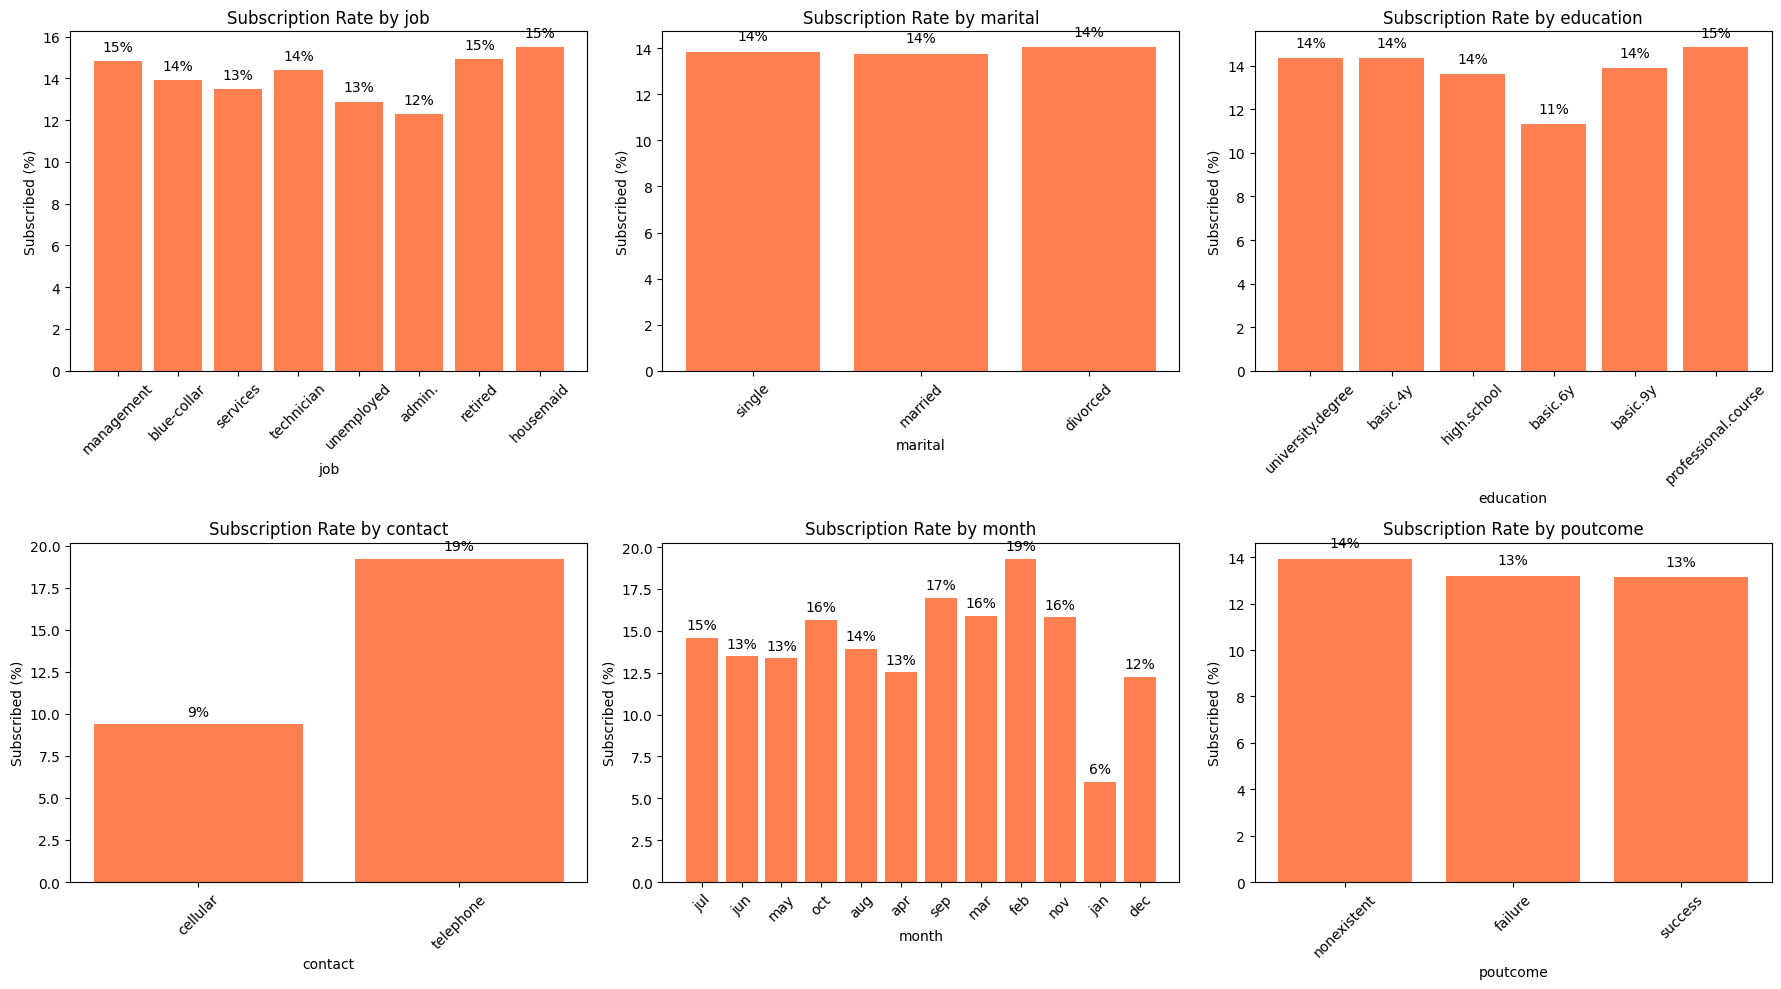

In [21]:
# For each category, what % subscribed?
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Calculate subscription rate for each category
    rate = []
    categories = X_train[col].unique()
    
    for cat in categories:
        mask = X_train[col] == cat
        sub_rate = y_train[mask].mean() * 100
        rate.append(sub_rate)
    
    # Plot
    axes[i].bar(categories, rate, color='coral')
    axes[i].set_title(f'Subscription Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Subscribed (%)')
    axes[i].tick_params(axis='x', rotation=45)
    
    for j, r in enumerate(rate):
        axes[i].text(j, r + 0.5, f'{r:.0f}%', ha='center')

plt.tight_layout()
plt.show()

In [22]:
print("="*50)
print("KEY FINDINGS FROM EDA")
print("="*50)

# Class imbalance
print(f"1. Dataset is imbalanced: {y_train.mean()*100:.1f}% subscribed")

# Best predictor
best = X_train['duration'].corr(y_train)
print(f"2. Duration has strongest correlation with target: {best:.3f}")

# Best categorical
for col in ['poutcome', 'month', 'contact']:
    rates = []
    for cat in X_train[col].unique():
        rate = y_train[X_train[col] == cat].mean()
        rates.append((cat, rate))
    best_cat = max(rates, key=lambda x: x[1])
    print(f"3. Best {col}: {best_cat[0]} ({best_cat[1]*100:.0f}% subscription)")

# Unknown values
for col in X_train.columns:
    unknown = (X_train[col] == 'unknown').sum()
    if unknown > 0:
        print(f"4. {col} has {unknown} unknown values (need cleaning)")

KEY FINDINGS FROM EDA
1. Dataset is imbalanced: 13.8% subscribed
2. Duration has strongest correlation with target: 0.450
3. Best poutcome: nonexistent (14% subscription)
3. Best month: feb (19% subscription)
3. Best contact: telephone (19% subscription)


---
### Data Cleaning

In [23]:
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

- **Handle Outliers**

In [25]:
# Numerical columns to check
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 
            'euribor3m', 'emp.var.rate', 'cons.price.idx', 
            'cons.conf.idx', 'nr.employed']

# Cap outliers using IQR method
for col in num_cols:
    Q1 = X_train_clean[col].quantile(0.25)
    Q3 = X_train_clean[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    X_train_clean[col] = X_train_clean[col].clip(lower, upper)
    X_test_clean[col] = X_test_clean[col].clip(lower, upper)
    


- **Encoding**

In [26]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
            'contact', 'month', 'day_of_week', 'poutcome']

ohe = OneHotEncoder(sparse_output=False, drop='first')  

X_train_encoded = ohe.fit_transform(X_train_clean[cat_cols])
X_test_encoded = ohe.transform(X_test_clean[cat_cols])

# Get feature names
encoded_feature_names = ohe.get_feature_names_out(cat_cols)

X_train_encoded

array([[0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(12000, 35))

- **Combine Numerical + Encoded Categorical**

In [27]:
X_train_numerical = X_train_clean[num_cols].values
X_test_numerical = X_test_clean[num_cols].values


# Combine numerical and encoded categorical
X_train_final = np.hstack([X_train_numerical, X_train_encoded])
X_test_final = np.hstack([X_test_numerical, X_test_encoded])

print(f"Training data shape: {X_train_final.shape}")
print(f"Test data shape: {X_test_final.shape}")

Training data shape: (12000, 45)
Test data shape: (3000, 45)


- **Scaling**

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

---
### Save Cleaned Dataset

In [29]:
X_train_clean.to_csv('X_train_cleaned.csv', index=False)
X_test_clean.to_csv('X_test_cleaned.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

---
### PCA (Principal Component Analysis)

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

In [31]:
# transform training
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform test data 
X_test_pca = pca.transform(X_test_scaled)

In [32]:
print(f"Original features: {X_train_scaled.shape[1]}")
print(f"After PCA: {X_train_pca.shape[1]} features")
print(f"Variance kept: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Original features: 45
After PCA: 35 features
Variance kept: 95.5%


---
## Building Model

In [33]:
from sklearn.svm import SVC

svm = SVC(class_weight='balanced',probability= True ,random_state=42)


- **Parameters Lists**

In [44]:
param = {
    'svm__C': [50, 100, 200, 500],
    'svm__kernel': ['rbf'],
    'svm__gamma': [0.001, 0.005, 0.01, 0.05],
    'svm__class_weight': ['balanced', {0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 8}],
    'svm__probability': [True],
    'svm__random_state': [42],
    'svm': [SVC()]
}

- **Pipline**

In [45]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([('svm' , svm)])

- **GridSearchCV**

In [46]:
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(pipeline , param , cv=3 , scoring= 'f1' , verbose=2 , n_jobs= -1 )

gs.fit(X_train_pca , y_train)

Fitting 3 folds for each of 64 candidates, totalling 192 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm': [SVC()], 'svm__C': [50, 100, ...], 'svm__class_weight': ['balanced', {0: 1, 1: 3}, ...], 'svm__gamma': [0.001, 0.005, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [47]:
print(f'Best Parameters: {gs.best_params_}')
print(f'Best F1 Score: {gs.best_score_}')

Best Parameters: {'svm': SVC(), 'svm__C': 200, 'svm__class_weight': {0: 1, 1: 3}, 'svm__gamma': 0.005, 'svm__kernel': 'rbf', 'svm__probability': True, 'svm__random_state': 42}
Best F1 Score: 0.79116469321106


- **Predict on Test Set**

In [48]:
y_pred = gs.predict(X_test_pca)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

---
### Model Evaluation

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [50]:
print("MODEL EVALUATION METRICS\n")

print(f"Accuracy:   {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:  {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:     {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:   {f1:.4f} ({f1*100:.2f}%)")

print("\nCalssification Report\n")
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))


MODEL EVALUATION METRICS

Accuracy:   0.9517 (95.17%)
Precision:  0.8386 (83.86%)
Recall:     0.8128 (81.28%)
F1-Score:   0.8255 (82.55%)

Calssification Report

              precision    recall  f1-score   support

      No (0)       0.97      0.97      0.97      2578
     Yes (1)       0.84      0.81      0.83       422

    accuracy                           0.95      3000
   macro avg       0.90      0.89      0.90      3000
weighted avg       0.95      0.95      0.95      3000



---
### Create Pipeline

In [51]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 
            'euribor3m', 'emp.var.rate', 'cons.price.idx', 
            'cons.conf.idx', 'nr.employed']

cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
            'contact', 'month', 'day_of_week', 'poutcome']

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# Pipeline with SMOTE
pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.3, random_state=42)),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(
        C=2,
        kernel='rbf',
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

# Train
pipeline.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The g

In [53]:
# Predict probabilities
y_proba = pipeline.predict_proba(X_test)[:, 1]

- **Find best threshold**

In [54]:

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx] if len(thresholds) > 0 else 0.5

print(f"Best threshold: {best_threshold:.3f}")

Best threshold: 0.692


- **Predict with best threshold**

In [55]:
y_pred = (y_proba >= best_threshold).astype(int)

- **Evaluate**

In [56]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2578
           1       0.96      0.92      0.94       422

    accuracy                           0.98      3000
   macro avg       0.97      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000

Confusion Matrix:
[[2561   17]
 [  32  390]]


---
### Save Model

In [58]:
joblib.dump(pipeline, 'best_svm_model.pkl')

['best_svm_model.pkl']